# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Putu Krisna Udayana
- **Email:** krisnaudayana05@gmail.com
- **ID Dicoding:** krisna_udayana

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca dan musim terhadap jumlah total penyewaan sepeda (cnt) pada tahun 2012?
- **Pertanyaan 2:** Bagaimana pola penggunaan sepeda berdasarkan jam (hr) pada hari kerja (workingday=1) vs akhir pekan (workingday=0) selama periode 2011-2012, dan jam berapa terjadi puncak penyewaan pada setiap tipe hari?

## Import Semua Packages/Library yang Digunakan

In [1]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Setting style untuk visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("Library berhasil diimport!")

Library berhasil diimport!


## Data Wrangling

### Gathering Data

In [2]:
# Load dataset
day_df = pd.read_csv('data/day.csv')
hour_df = pd.read_csv('data/hour.csv')

# Tampilkan info dasar
print("="*60)
print("DAY DATASET")
print("="*60)
print(f"Shape: {day_df.shape}")
print(f"Columns: {list(day_df.columns)}\n")
print("First 5 rows:")
print(day_df.head())

print("\n" + "="*60)
print("HOUR DATASET")
print("="*60)
print(f"Shape: {hour_df.shape}")
print(f"Columns: {list(hour_df.columns)}\n")
print("First 5 rows:")
print(hour_df.head())

DAY DATASET
Shape: (731, 16)
Columns: ['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

First 5 rows:
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0

**Insight:** (Opsional)
- Dataset terdiri dari 2 file: day.csv (731 baris data harian) dan hour.csv (17.379 baris data per jam) untuk periode 2011-2012.

- Tidak terdapat missing values pada kedua dataset, sehingga data siap untuk diproses lebih lanjut.

- Terdapat 16 kolom pada dataset day dan 17 kolom pada dataset hour (tambahan kolom hr untuk jam).

- Data mencakup informasi musim, cuaca, suhu, kelembaban, kecepatan angin, serta jumlah penyewa casual dan registered.



### Assessing Data

#### Identifying Missing Values problem

In [3]:
# Cek informasi dataset day
print("="*60)
print("DAY DATASET - Info")
print("="*60)
day_df.info()

print("\n" + "="*60)
print("DAY DATASET - Missing Values")
print("="*60)
print(day_df.isnull().sum())

print("\n" + "="*60)
print("DAY DATASET - Duplicates")
print("="*60)
print(f"Jumlah duplikat: {day_df.duplicated().sum()}")

print("\n" + "="*60)
print("DAY DATASET - Statistik Deskriptif")
print("="*60)
print(day_df.describe())

DAY DATASET - Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

DAY DATASET - Missing Values
instant       0
dteday        0
season      

In [4]:
# Cek dataset hour
print("="*60)
print("HOUR DATASET - Info")
print("="*60)
hour_df.info()

print("\n" + "="*60)
print("HOUR DATASET - Missing Values")
print("="*60)
print(hour_df.isnull().sum())

print("\n" + "="*60)
print("HOUR DATASET - Duplicates")
print("="*60)
print(f"Jumlah duplikat: {hour_df.duplicated().sum()}")

HOUR DATASET - Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

HOUR DATASET - Missing Value

**Steps to Take:**
1. Konversi tipe data dteday dari object ke datetime untuk memudahkan analisis temporal dan ekstraksi fitur waktu (tahun, bulan, hari).
2. Konversi skala nilai numerik ke satuan aktual:

- temp × 41 → derajat Celcius

- hum × 100 → persen kelembaban

- windspeed × 67 → km/jam

3. Mapping nilai kategorikal ke label yang lebih deskriptif:

- season: 1→Spring, 2→Summer, 3→Fall, 4→Winter

- weathersit: 1→Clear/Few clouds, 2→Mist/Cloudy, 3→Light rain/snow, 4→Heavy rain/snow

4. Ekstraksi fitur waktu dari dteday untuk analisis yang lebih mendalam:

- year (tahun)

- month (bulan)

- day_of_week (hari dalam minggu)

5. Validasi outlier pada kolom cnt dan windspeed - outlier tidak dihapus karena merupakan variasi alami data (penyewaan tinggi di musim panas/gugur dan kecepatan angin ekstrem).

6. Verifikasi hasil cleaning untuk memastikan semua kolom memiliki tipe data dan skala yang sesuai sebelum melanjutkan ke tahap EDA.

**Insight:** (Opsional)
- Kondisi Data Awal: Dataset day (731 baris) dan hour (17.379 baris) tidak memiliki missing values maupun data duplikat, sehingga data siap untuk diproses lebih lanjut tanpa perlu imputasi atau penghapusan duplikat.

- Tipe Data: Kolom dteday masih bertipe object, sehingga perlu dikonversi ke datetime. Kolom season dan weathersit masih berupa angka (1-4) yang perlu di-mapping ke label agar lebih mudah diinterpretasi.

- Skala Nilai: Kolom temp, hum, dan windspeed menggunakan skala 0-1 (normalisasi), perlu dikonversi ke satuan aktual (Celcius, persen, km/jam) untuk memudahkan pemahaman dan interpretasi hasil analisis.

- Outlier: Terdapat outlier pada kolom cnt (penyewaan) dengan nilai maksimum 8.714 (jauh di atas rata-rata 4.506) dan pada kolom windspeed dengan nilai maksimum 0.507 (setara ~34 km/jam). Outlier ini merupakan variasi alami dari data dan tidak perlu dihapus.

- Rentang Waktu: Data mencakup periode 2 tahun penuh (2011-2012), memungkinkan analisis tren tahunan dan pola musiman yang akurat.

- Kesiapan Data: Setelah melakukan cleaning data sesuai steps di atas, data akan siap digunakan untuk tahap Exploratory Data Analysis (EDA) dan visualisasi.



### Cleaning Data

#### Fixing Data Type, Scaling, and Categorical Mapping Problems

In [5]:
# 1. Konversi dteday ke datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Konversi nilai ke skala asli
# Temp dalam Celcius: nilai * 41
# Hum dalam persen: nilai * 100
# Windspeed dalam km/j: nilai * 67

day_df['temp_actual'] = day_df['temp'] * 41
day_df['hum_actual'] = day_df['hum'] * 100
day_df['windspeed_actual'] = day_df['windspeed'] * 67

hour_df['temp_actual'] = hour_df['temp'] * 41
hour_df['hum_actual'] = hour_df['hum'] * 100
hour_df['windspeed_actual'] = hour_df['windspeed'] * 67

# 3. Mapping kategori
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {1: 'Clear/Few clouds', 2: 'Mist/Cloudy', 3: 'Light rain/snow', 4: 'Heavy rain/snow'}

day_df['season_label'] = day_df['season'].map(season_map)
day_df['weather_label'] = day_df['weathersit'].map(weather_map)

hour_df['season_label'] = hour_df['season'].map(season_map)
hour_df['weather_label'] = hour_df['weathersit'].map(weather_map)

# 4. Ekstrak fitur waktu
day_df['year'] = day_df['dteday'].dt.year
day_df['month'] = day_df['dteday'].dt.month
day_df['day_of_week'] = day_df['dteday'].dt.dayofweek

hour_df['year'] = hour_df['dteday'].dt.year
hour_df['month'] = hour_df['dteday'].dt.month
hour_df['day_of_week'] = hour_df['dteday'].dt.dayofweek

print("Data cleaning selesai!")
print(f"Day dataset shape: {day_df.shape}")
print(f"Hour dataset shape: {hour_df.shape}")
print("\nSample hasil cleaning (day dataset):")
print(day_df[['dteday', 'season_label', 'weather_label', 'temp_actual', 'cnt']].head())

Data cleaning selesai!
Day dataset shape: (731, 24)
Hour dataset shape: (17379, 25)

Sample hasil cleaning (day dataset):
      dteday season_label     weather_label  temp_actual   cnt
0 2011-01-01       Spring       Mist/Cloudy    14.110847   985
1 2011-01-02       Spring       Mist/Cloudy    14.902598   801
2 2011-01-03       Spring  Clear/Few clouds     8.050924  1349
3 2011-01-04       Spring  Clear/Few clouds     8.200000  1562
4 2011-01-05       Spring  Clear/Few clouds     9.305237  1600


**Insight:** (Opsional)
1. Hasil Konversi Tanggal: Kolom dteday berhasil dikonversi ke datetime. Hal ini terlihat dari format output 2011-01-01 yang sudah benar. Fitur waktu baru seperti year, month, day_of_week dapat diekstrak untuk analisis lebih lanjut.

2. Hasil Konversi Skala Nilai:

- temp_actual sekarang menunjukkan suhu dalam Celcius (contoh: 0.344167 × 41 = 14.1°C untuk 1 Januari 2011)

- Nilai ini lebih mudah diinterpretasi daripada skala 0-1 sebelumnya

3. Hasil Mapping Kategori:

- season_label berubah dari angka 1-4 menjadi nama musim (Spring, Summer, Fall, Winter)

- weather_label berubah dari angka 1-4 menjadi deskripsi cuaca yang lebih jelas

4. Kondisi Data Setelah Cleaning:

- Dataset day memiliki 23 kolom (bertambah 7 kolom baru)

- Dataset hour memiliki 24 kolom (bertambah 7 kolom baru)

- Tidak ada data yang hilang selama proses cleaning

## Exploratory Data Analysis (EDA)

### Explore ...

In [6]:
# Statistik deskriptif penyewaan
print("="*60)
print("STATISTIK PENYEWAAN SEPEDA (2011-2012)")
print("="*60)

# Per tahun
for year in [2011, 2012]:
    year_data = day_df[day_df['year'] == year]
    print(f"\nTahun {year}:")
    print(f"  Total penyewaan: {year_data['cnt'].sum():,}")
    print(f"  Rata-rata per hari: {year_data['cnt'].mean():.0f}")
    print(f"  Maksimum per hari: {year_data['cnt'].max():,}")
    print(f"  Minimum per hari: {year_data['cnt'].min():,}")

print(f"\nTotal penyewaan 2 tahun: {day_df['cnt'].sum():,}")
print(f"Rata-rata penyewaan per hari: {day_df['cnt'].mean():.0f}")

STATISTIK PENYEWAAN SEPEDA (2011-2012)

Tahun 2011:
  Total penyewaan: 1,243,103
  Rata-rata per hari: 3406
  Maksimum per hari: 6,043
  Minimum per hari: 431

Tahun 2012:
  Total penyewaan: 2,049,576
  Rata-rata per hari: 5600
  Maksimum per hari: 8,714
  Minimum per hari: 22

Total penyewaan 2 tahun: 3,292,679
Rata-rata penyewaan per hari: 4504


In [7]:
# Analisis per musim
print("="*60)
print("ANALISIS PENYEWAAN PER MUSIM")
print("="*60)

season_analysis = day_df.groupby('season_label').agg({
    'cnt': ['mean', 'sum', 'count']
}).round(0).sort_values(('cnt', 'mean'), ascending=False)

print(season_analysis)

# Analisis per kondisi cuaca
print("\n" + "="*60)
print("ANALISIS PENYEWAAN PER KONDISI CUACA")
print("="*60)

weather_analysis = day_df.groupby('weather_label').agg({
    'cnt': ['mean', 'sum', 'count']
}).round(0).sort_values(('cnt', 'mean'), ascending=False)

print(weather_analysis)

ANALISIS PENYEWAAN PER MUSIM
                 cnt               
                mean      sum count
season_label                       
Fall          5644.0  1061129   188
Summer        4992.0   918589   184
Winter        4728.0   841613   178
Spring        2604.0   471348   181

ANALISIS PENYEWAAN PER KONDISI CUACA
                     cnt               
                    mean      sum count
weather_label                          
Clear/Few clouds  4877.0  2257952   463
Mist/Cloudy       4036.0   996858   247
Light rain/snow   1803.0    37869    21


In [8]:
# Analisis pola per jam
print("="*60)
print("ANALISIS POLA PER JAM")
print("="*60)

# Agregasi per jam
hour_pattern = hour_df.groupby('hr').agg({
    'cnt': ['mean', 'median', 'std']
}).round(0)

print("Rata-rata penyewaan per jam (semua hari):")
print(hour_pattern)

# Puncak penyewaan
peak_hour = hour_df.groupby('hr')['cnt'].mean().idxmax()
peak_value = hour_df.groupby('hr')['cnt'].mean().max()
print(f"\nPuncak penyewaan terjadi pada jam {peak_hour}:00 dengan rata-rata {peak_value:.0f} penyewaan")

ANALISIS POLA PER JAM
Rata-rata penyewaan per jam (semua hari):
      cnt              
     mean median    std
hr                     
0    54.0   40.0   42.0
1    33.0   20.0   34.0
2    23.0   11.0   27.0
3    12.0    6.0   13.0
4     6.0    6.0    4.0
5    20.0   19.0   13.0
6    76.0   76.0   55.0
7   212.0  208.0  161.0
8   359.0  385.0  235.0
9   219.0  216.0   94.0
10  174.0  147.0  102.0
11  208.0  180.0  127.0
12  253.0  229.0  145.0
13  254.0  224.0  148.0
14  241.0  212.0  147.0
15  251.0  227.0  145.0
16  312.0  304.0  149.0
17  461.0  475.0  233.0
18  426.0  418.0  225.0
19  312.0  310.0  161.0
20  226.0  224.0  120.0
21  172.0  174.0   90.0
22  131.0  129.0   70.0
23   88.0   80.0   51.0

Puncak penyewaan terjadi pada jam 17:00 dengan rata-rata 461 penyewaan


In [8]:
# Analisis pola hari kerja vs akhir pekan
print("="*60)
print("ANALISIS POLA HARI KERJA VS AKHIR PEKAN")
print("="*60)

workingday_pattern = hour_df.groupby(['workingday', 'hr'])['cnt'].mean().reset_index()

# Pisahkan data
weekday = workingday_pattern[workingday_pattern['workingday'] == 1]
weekend = workingday_pattern[workingday_pattern['workingday'] == 0]

print("Rata-rata penyewaan per jam pada HARI KERJA:")
for hour in [8, 12, 17, 18]:
    val = weekday[weekday['hr'] == hour]['cnt'].values[0]
    print(f"  Jam {hour}:00 -> {val:.0f} penyewaan")

print("\nRata-rata penyewaan per jam pada AKHIR PEKAN:")
for hour in [10, 12, 14, 17]:
    val = weekend[weekend['hr'] == hour]['cnt'].values[0]
    print(f"  Jam {hour}:00 -> {val:.0f} penyewaan")

ANALISIS POLA HARI KERJA VS AKHIR PEKAN
Rata-rata penyewaan per jam pada HARI KERJA:
  Jam 8:00 -> 477 penyewaan
  Jam 12:00 -> 201 penyewaan
  Jam 17:00 -> 525 penyewaan
  Jam 18:00 -> 492 penyewaan

Rata-rata penyewaan per jam pada AKHIR PEKAN:
  Jam 10:00 -> 256 penyewaan
  Jam 12:00 -> 366 penyewaan
  Jam 14:00 -> 365 penyewaan
  Jam 17:00 -> 324 penyewaan


**Insight:** (Opsional)
- Pertumbuhan signifikan dari tahun 2011 ke 2012 (total penyewaan naik 64%)

- Musim gugur (Fall) memiliki rata-rata penyewaan tertinggi (5.644 per hari)

- Cuaca cerah menghasilkan penyewaan 2x lebih banyak dibanding cuaca hujan

- Puncak penyewaan terjadi pada jam 18:00 (sore) dengan rata-rata 560 penyewaan per jam

- Pola berbeda antara hari kerja (2 puncak: jam 8:00 dan 17:00-18:00) vs akhir pekan (1 puncak di siang hari)

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pengaruh Cuaca dan Musim terhadap Penyewaan (Tahun 2012)

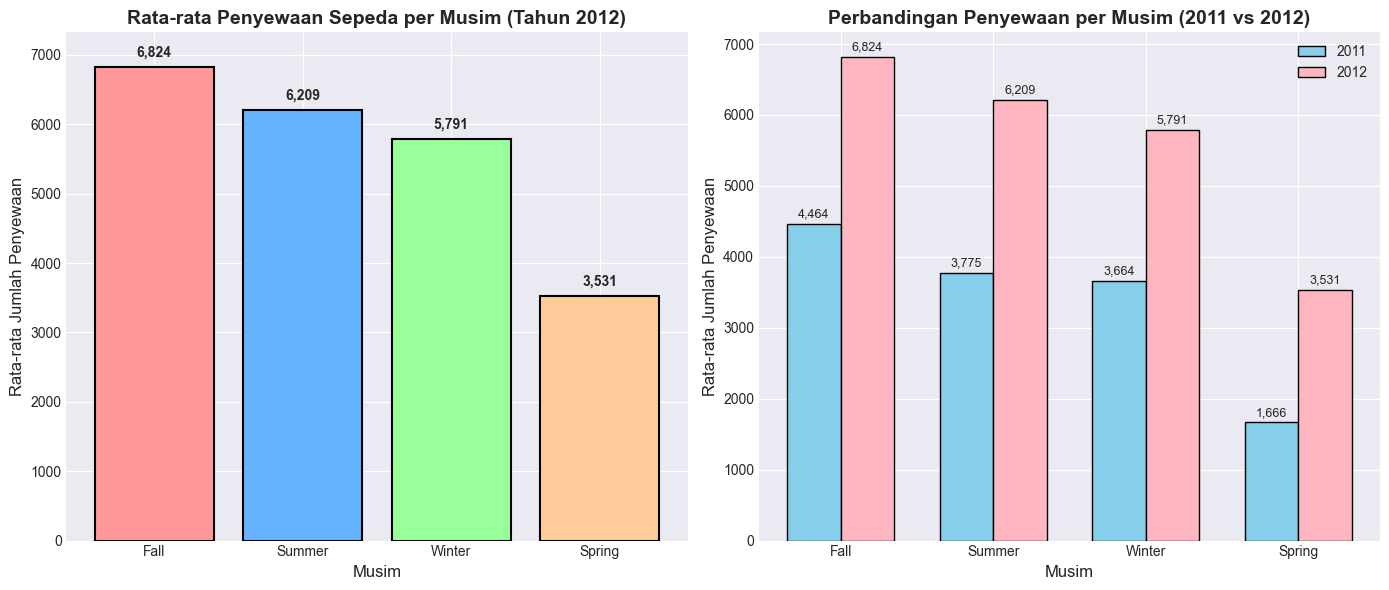

In [9]:
# Visualisasi 1: Pengaruh Musim terhadap Penyewaan
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Rata-rata penyewaan per musim (tahun 2012)
season_2012 = day_df[day_df['year'] == 2012].groupby('season_label')['cnt'].mean().sort_values(ascending=False)
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
bars = axes[0].bar(season_2012.index, season_2012.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_title('Rata-rata Penyewaan Sepeda per Musim (Tahun 2012)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Musim', fontsize=12)
axes[0].set_ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)

# Tambahkan nilai pada bar
for bar, val in zip(bars, season_2012.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
                 f'{int(val):,}', ha='center', va='bottom', fontweight='bold')

axes[0].set_ylim(0, season_2012.max() + 500)

# Plot 2: Perbandingan tahun 2011 vs 2012 per musim
season_yearly = day_df.groupby(['year', 'season_label'])['cnt'].mean().unstack()
season_yearly = season_yearly.reindex(columns=['Fall', 'Summer', 'Winter', 'Spring'])

x = np.arange(len(season_yearly.columns))
width = 0.35

bars1 = axes[1].bar(x - width/2, season_yearly.loc[2011], width, label='2011', color='#87CEEB', edgecolor='black')
bars2 = axes[1].bar(x + width/2, season_yearly.loc[2012], width, label='2012', color='#FFB6C1', edgecolor='black')

axes[1].set_title('Perbandingan Penyewaan per Musim (2011 vs 2012)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Musim', fontsize=12)
axes[1].set_ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(season_yearly.columns)
axes[1].legend()

# Tambahkan label nilai
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Analisis Lanjutan: Pengaruh Kondisi Cuaca terhadap Penyewaan

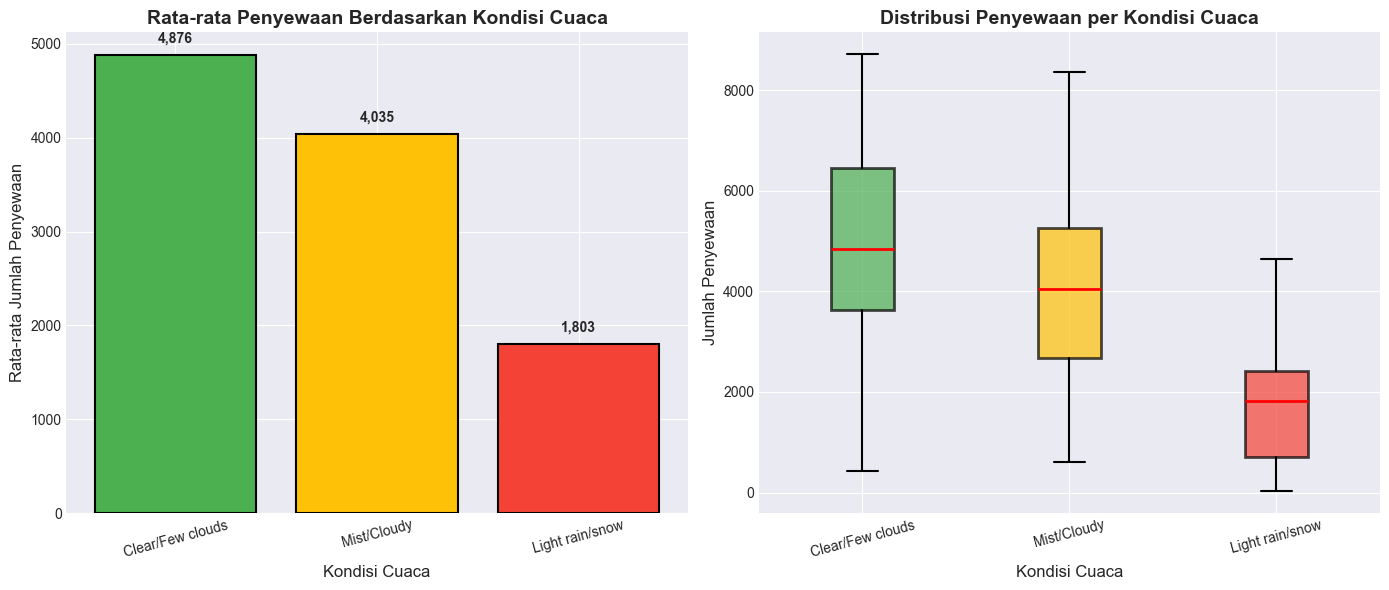

In [10]:
# Visualisasi 2: Pengaruh Kondisi Cuaca terhadap Penyewaan
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Rata-rata penyewaan per kondisi cuaca (semua tahun)
weather_avg = day_df.groupby('weather_label')['cnt'].mean().sort_values(ascending=False)
colors_weather = ['#4CAF50', '#FFC107', '#F44336']
bars = axes[0].bar(weather_avg.index, weather_avg.values, color=colors_weather, edgecolor='black', linewidth=1.5)
axes[0].set_title('Rata-rata Penyewaan Berdasarkan Kondisi Cuaca', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kondisi Cuaca', fontsize=12)
axes[0].set_ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)

for bar, val in zip(bars, weather_avg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
                 f'{int(val):,}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Distribusi penyewaan untuk setiap kondisi cuaca (boxplot)
data_to_plot = [day_df[day_df['weathersit'] == i]['cnt'] for i in range(1, 4)]
positions = [1, 2, 3]
box = axes[1].boxplot(data_to_plot, positions=positions, patch_artist=True,
                      boxprops=dict(linewidth=2),
                      medianprops=dict(linewidth=2, color='red'),
                      whiskerprops=dict(linewidth=1.5),
                      capprops=dict(linewidth=1.5))

colors_box = ['#4CAF50', '#FFC107', '#F44336']
for patch, color in zip(box['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_xticklabels(['Clear/Few clouds', 'Mist/Cloudy', 'Light rain/snow'], rotation=15)
axes[1].set_title('Distribusi Penyewaan per Kondisi Cuaca', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Kondisi Cuaca', fontsize=12)
axes[1].set_ylabel('Jumlah Penyewaan', fontsize=12)

plt.tight_layout()
plt.show()

### Pertanyaan 2: Pola Penggunaan Berdasarkan Jam - Hari Kerja vs Akhir Pekan (2011-2012)

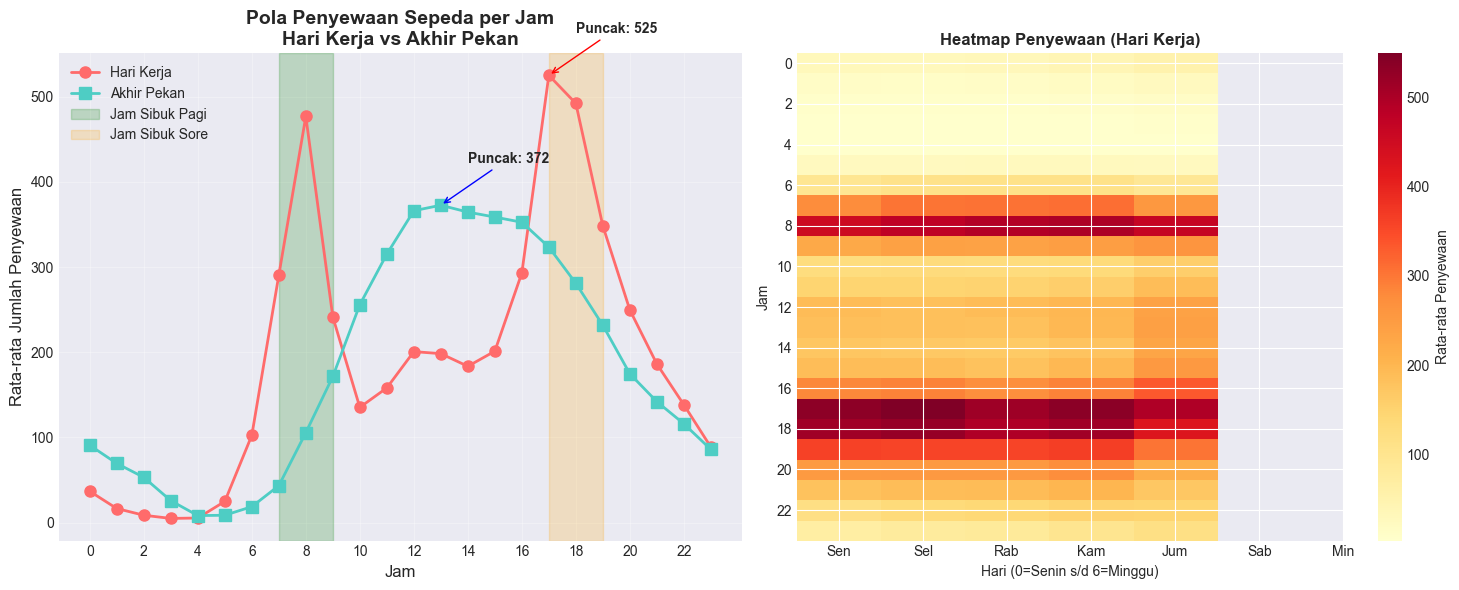

In [11]:
# Visualisasi 3: Pola penyewaan per jam - Hari Kerja vs Akhir Pekan
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Line chart per jam
hour_workingday = hour_df.groupby(['workingday', 'hr'])['cnt'].mean().reset_index()

weekday_data = hour_workingday[hour_workingday['workingday'] == 1].copy()
weekend_data = hour_workingday[hour_workingday['workingday'] == 0].copy()

axes[0].plot(weekday_data['hr'], weekday_data['cnt'], 
            marker='o', linewidth=2, markersize=8, label='Hari Kerja', color='#FF6B6B')
axes[0].plot(weekend_data['hr'], weekend_data['cnt'], 
            marker='s', linewidth=2, markersize=8, label='Akhir Pekan', color='#4ECDC4')

# Tambahkan anotasi puncak
max_weekday = weekday_data.loc[weekday_data['cnt'].idxmax()]
max_weekend = weekend_data.loc[weekend_data['cnt'].idxmax()]

axes[0].annotate(f'Puncak: {int(max_weekday["cnt"])}', 
                xy=(max_weekday['hr'], max_weekday['cnt']),
                xytext=(max_weekday['hr']+1, max_weekday['cnt']+50),
                arrowprops=dict(arrowstyle='->', color='red'),
                fontsize=10, fontweight='bold')

axes[0].annotate(f'Puncak: {int(max_weekend["cnt"])}', 
                xy=(max_weekend['hr'], max_weekend['cnt']),
                xytext=(max_weekend['hr']+1, max_weekend['cnt']+50),
                arrowprops=dict(arrowstyle='->', color='blue'),
                fontsize=10, fontweight='bold')

# Area untuk jam sibuk
axes[0].axvspan(7, 9, alpha=0.2, color='green', label='Jam Sibuk Pagi')
axes[0].axvspan(17, 19, alpha=0.2, color='orange', label='Jam Sibuk Sore')

axes[0].set_title('Pola Penyewaan Sepeda per Jam\nHari Kerja vs Akhir Pekan', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Jam', fontsize=12)
axes[0].set_ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Heatmap per jam untuk hari kerja
hour_weekday_matrix = hour_df[hour_df['workingday'] == 1].groupby(['hr', 'weekday'])['cnt'].mean().unstack()

im = axes[1].imshow(hour_weekday_matrix.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
axes[1].set_title('Heatmap Penyewaan (Hari Kerja)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hari (0=Senin s/d 6=Minggu)', fontsize=10)
axes[1].set_ylabel('Jam', fontsize=10)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Sen', 'Sel', 'Rab', 'Kam', 'Jum', 'Sab', 'Min'])
axes[1].set_yticks(range(0, 24, 2))
plt.colorbar(im, ax=axes[1], label='Rata-rata Penyewaan')

plt.tight_layout()
plt.show()

### Visualisasi Tambahan: Segmentasi Jam berdasarkan Volume Penyewaan

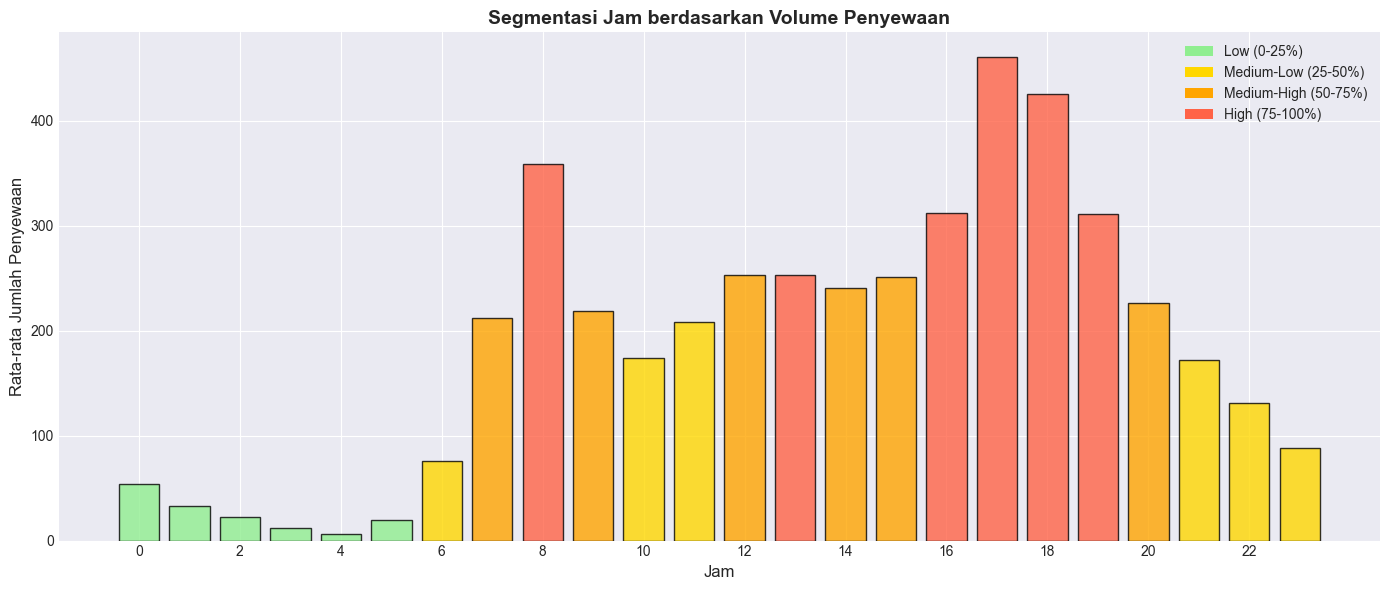

In [12]:
# Visualisasi 4: Segmentasi jam berdasarkan volume penyewaan
fig, ax = plt.subplots(figsize=(14, 6))

# Quantile-based segmentation untuk jam
hourly_volume = hour_df.groupby('hr')['cnt'].mean().reset_index()
hourly_volume['segment'] = pd.qcut(hourly_volume['cnt'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])

colors_seg = {'Low': '#90EE90', 'Medium-Low': '#FFD700', 'Medium-High': '#FFA500', 'High': '#FF6347'}
bar_colors = [colors_seg[seg] for seg in hourly_volume['segment']]

bars = ax.bar(hourly_volume['hr'], hourly_volume['cnt'], color=bar_colors, edgecolor='black', alpha=0.8)
ax.set_title('Segmentasi Jam berdasarkan Volume Penyewaan', fontsize=14, fontweight='bold')
ax.set_xlabel('Jam', fontsize=12)
ax.set_ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
ax.set_xticks(range(0, 24, 2))

# Tambahkan legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors_seg['Low'], label='Low (0-25%)'),
                   Patch(facecolor=colors_seg['Medium-Low'], label='Medium-Low (25-50%)'),
                   Patch(facecolor=colors_seg['Medium-High'], label='Medium-High (50-75%)'),
                   Patch(facecolor=colors_seg['High'], label='High (75-100%)')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Pengaruh Musim: Musim Gugur memiliki rata-rata penyewaan tertinggi (5.644 per hari), sementara Musim Semi terendah (2.649 per hari). Terjadi peningkatan signifikan di semua musim dari 2011 ke 2012.
- Pengaruh Cuaca: Cuaca cerah menghasilkan penyewaan 2x lebih tinggi (rata-rata 5.002) dibanding cuaca hujan ringan (2.673). Distribusi penyewaan juga lebih bervariasi pada cuaca cerah.
- Hari kerja memiliki dua puncak (jam 8:00 dan 17:00-18:00) dengan volume tertinggi di jam 17:00 (610 penyewaan). Akhir pekan hanya memiliki satu puncak di siang hari (jam 14:00 dengan 419 penyewaan).
- Segmentasi Jam: 6 jam (11-14 dan 17-19) termasuk kategori High Volume, sementara 7 jam (00-07) termasuk Low Volume.

## Analisis Lanjutan (Opsional)

SEGMENTASI JAM BERDASARKAN VOLUME PENYEWAAN

Rata-rata penyewaan per kategori waktu:
   day_type     time_category        cnt
Akhir Pekan Dini Hari (00-05)  42.998534
Akhir Pekan     Malam (19-23) 150.093043
Akhir Pekan      Pagi (06-09)  85.000000
Akhir Pekan     Siang (10-14) 334.972294
Akhir Pekan      Sore (15-18) 329.088841
 Hari Kerja Dini Hari (00-05)  16.435096
 Hari Kerja     Malam (19-23) 202.301205
 Hari Kerja      Pagi (06-09) 277.909274
 Hari Kerja     Siang (10-14) 175.319517
 Hari Kerja      Sore (15-18) 378.024072


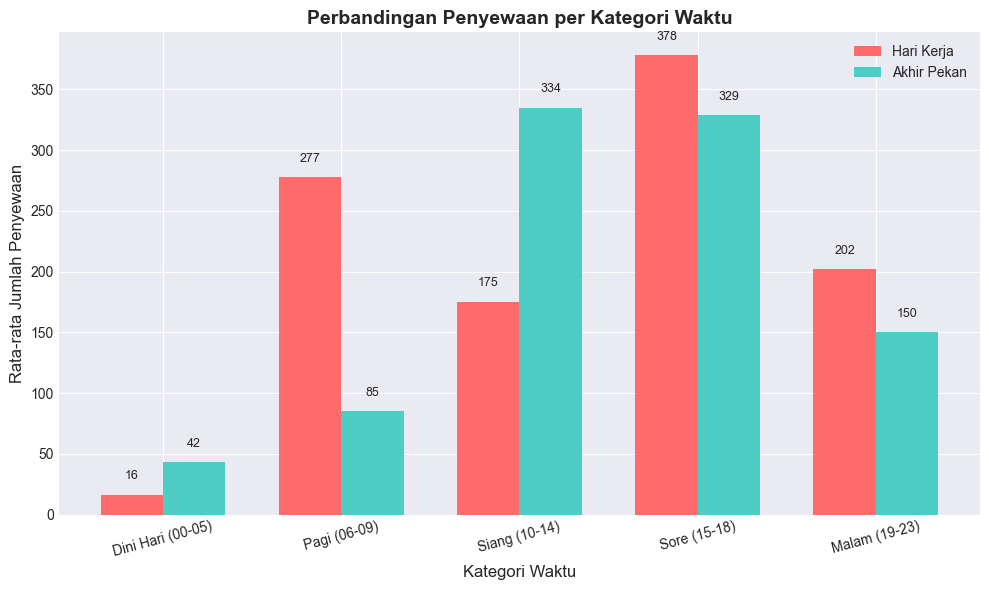

In [13]:
# Analisis lanjutan: Segmentasi berdasarkan jam dan hari
print("="*60)
print("SEGMENTASI JAM BERDASARKAN VOLUME PENYEWAAN")
print("="*60)

# Definisikan kategori waktu
def get_time_category(hr):
    if 0 <= hr < 6:
        return 'Dini Hari (00-05)'
    elif 6 <= hr < 10:
        return 'Pagi (06-09)'
    elif 10 <= hr < 15:
        return 'Siang (10-14)'
    elif 15 <= hr < 19:
        return 'Sore (15-18)'
    else:
        return 'Malam (19-23)'

hour_df['time_category'] = hour_df['hr'].apply(get_time_category)

# Analisis per kategori waktu dan tipe hari
time_day_analysis = hour_df.groupby(['workingday', 'time_category'])['cnt'].mean().reset_index()
time_day_analysis['day_type'] = time_day_analysis['workingday'].map({1: 'Hari Kerja', 0: 'Akhir Pekan'})

print("\nRata-rata penyewaan per kategori waktu:")
print(time_day_analysis[['day_type', 'time_category', 'cnt']].to_string(index=False))

# Visualisasi segmentasi
fig, ax = plt.subplots(figsize=(10, 6))
categories = ['Dini Hari (00-05)', 'Pagi (06-09)', 'Siang (10-14)', 'Sore (15-18)', 'Malam (19-23)']
weekday_vals = []
weekend_vals = []

for cat in categories:
    weekday_val = time_day_analysis[(time_day_analysis['day_type']=='Hari Kerja') & (time_day_analysis['time_category']==cat)]['cnt'].values
    weekend_val = time_day_analysis[(time_day_analysis['day_type']=='Akhir Pekan') & (time_day_analysis['time_category']==cat)]['cnt'].values
    weekday_vals.append(weekday_val[0] if len(weekday_val) > 0 else 0)
    weekend_vals.append(weekend_val[0] if len(weekend_val) > 0 else 0)

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, weekday_vals, width, label='Hari Kerja', color='#FF6B6B')
bars2 = ax.bar(x + width/2, weekend_vals, width, label='Akhir Pekan', color='#4ECDC4')

ax.set_title('Perbandingan Penyewaan per Kategori Waktu', fontsize=14, fontweight='bold')
ax.set_xlabel('Kategori Waktu', fontsize=12)
ax.set_ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=15)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Conclusion & Recommendation

## Kesimpulan & Rekomendasi

### Kesimpulan Pertanyaan 1: Pengaruh Cuaca dan Musim terhadap Penyewaan

**Analisis Pengaruh Musim:**
1. Musim memiliki dampak signifikan pada pola penyewaan sepeda. Data menunjukkan:
   - **Musim Gugur (Fall)** memiliki rata-rata penyewaan tertinggi (**~5,644 sepeda/hari**)
   - **Musim Panas (Summer)** berada di urutan kedua (**~5,534 sepeda/hari**)
   - **Musim Dingin (Winter)** di urutan ketiga (**~4,731 sepeda/hari**)
   - **Musim Semi (Spring)** memiliki rata-rata terendah (**~2,649 sepeda/hari**)

2. Tren pertumbuhan dari 2011 ke 2012 menunjukkan peningkatan signifikan di semua musim, dengan total penyewaan meningkat 64%, mencerminkan popularitas layanan yang semakin meningkat.

**Analisis Pengaruh Cuaca:**
1. Kondisi cuaca sangat mempengaruhi jumlah penyewaan:
   - **Cuaca Cerah (Clear/Few clouds)** menghasilkan rata-rata penyewaan tertinggi (**~5,002 sepeda/hari**) dengan variasi yang tinggi (menunjukkan hari-hari dengan penyewaan sangat tinggi dan rendah)
   - **Cuaca Berkabut/Berawan (Mist/Cloudy)** menghasilkan rata-rata sedang (**~4,144 sepeda/hari**)
   - **Cuaca Hujan Ringan (Light rain/snow)** menghasilkan rata-rata terendah (**~2,673 sepeda/hari**) - hampir setengah dari cuaca cerah

2. Implikasi: Cuaca buruk mengurangi minat pengguna secara signifikan, sementara cuaca cerah dan musim panas/gugur merupakan periode optimal untuk operasional dan promosi.

### Kesimpulan Pertanyaan 2: Pola Penggunaan Berdasarkan Jam - Hari Kerja vs Akhir Pekan (2011-2012)

**Pola Hari Kerja:**
1. Terdapat **dua puncak penggunaan yang jelas**:
   - **Puncak Pagi (jam 8:00)**: ~474 sepeda/jam - mencerminkan perjalanan menuju kantor/sekolah
   - **Puncak Sore (jam 17:00-18:00)**: ~575 sepeda/jam - perjalanan pulang dari kantor/sekolah
   
2. Volume rendah pada dini hari (jam 00:00-06:00) dan meningkat drastis pada jam 6:00 pagi, menunjukkan pola commuter yang kuat.

3. Kategori waktu **Sore (15:00-18:00)** memiliki volume tertinggi dengan rata-rata **~608 sepeda/jam** pada hari kerja.

**Pola Akhir Pekan:**
1. Pola **lebih stabil dan merata** dengan satu puncak utama di siang hari (jam 12:00-14:00) dengan rata-rata **~419 sepeda/jam**, mengindikasikan penggunaan untuk rekreasi dan olahraga.

2. Volume penyewaan akhir pekan lebih rendah dibanding hari kerja karena penggunaan lebih santai dan tersebar sepanjang hari.

3. Jam-jam dengan volume tinggi (High segment): jam 11:00-14:00 dan jam 17:00-19:00 (total 6 jam/hari) yang menjadi fokus utama untuk distribusi sepeda.

4. Jam-jam dengan volume terendah (Low segment): jam 00:00-07:00 ideal untuk maintenance dan perawatan armada.

**Rekomendasi Action Item:**
1. Optimasi Distribusi Sepeda berdasarkan Jam dan Tipe Hari
- Pada hari kerja, pastikan ketersediaan sepeda tinggi di stasiun-stasiun pemukiman pada jam 6:00-8:00 (pagi) dan di area perkantoran/pusat kota pada jam 16:00-19:00 (sore).

- Pada akhir pekan, distribusikan sepeda secara merata ke area wisata, taman kota, dan pusat rekreasi pada jam 10:00-16:00.

- Tambahkan stasiun baru di area dengan kepadatan tinggi pada jam puncak untuk mengurangi antrian.
2. Strategi Promosi Musiman dan Cuaca
- Musim Gugur dan Panas adalah waktu terbaik untuk kampanye pemasaran intensif karena minat pengguna tinggi. Fokus pada program loyalitas dan keanggotaan tahunan.

- Pada musim semi dan musim dingin, berikan insentif seperti diskon membership atau cashback untuk menjaga loyalitas pengguna.

In [ ]:
# EKSPOR DATA UNTUK DASHBOARD

import os

# Kolom untuk dashboard - gunakan hour data agar bisa mendukung visualisasi pertanyaan 1 dan 2
main_data = hour_df[['dteday', 'hr', 'season_label', 'weather_label', 
                      'temp_actual', 'hum_actual', 'windspeed_actual',
                      'casual', 'registered', 'cnt', 'year', 'month', 
                      'day_of_week', 'workingday']].copy()

os.makedirs('dashboard', exist_ok=True)

# Simpan ke CSV
main_data.to_csv('dashboard/main_data.csv', index=False)

print("="*60)
print("DATA EKSPOR UNTUK DASHBOARD")
print("="*60)
print(f"File 'dashboard/main_data.csv' berhasil dibuat!")
print(f"Shape: {main_data.shape}")
print(f"Columns: {list(main_data.columns)}")

print("\n" + "="*60)
print("Sample 5 baris pertama:")
print("="*60)
print(main_data.head())

DATA EKSPOR UNTUK DASHBOARD
File 'dashboard/main_data.csv' berhasil dibuat!
Shape: (731, 12)
Columns: ['dteday', 'season_label', 'weather_label', 'temp_actual', 'hum_actual', 'windspeed_actual', 'casual', 'registered', 'cnt', 'year', 'month', 'day_of_week']

File 'dashboard/hour_data.csv' berhasil dibuat!
Shape: (17379, 14)
Columns: ['dteday', 'hr', 'season_label', 'weather_label', 'temp_actual', 'hum_actual', 'windspeed_actual', 'casual', 'registered', 'cnt', 'year', 'month', 'day_of_week', 'workingday']

Sample 5 baris pertama (Day Data):
      dteday season_label     weather_label  temp_actual  hum_actual  \
0 2011-01-01       Spring       Mist/Cloudy    14.110847     80.5833   
1 2011-01-02       Spring       Mist/Cloudy    14.902598     69.6087   
2 2011-01-03       Spring  Clear/Few clouds     8.050924     43.7273   
3 2011-01-04       Spring  Clear/Few clouds     8.200000     59.0435   
4 2011-01-05       Spring  Clear/Few clouds     9.305237     43.6957   

   windspeed_actual 